# Pre-Processing

In [85]:
import numpy as np
import pandas as pd
import scipy
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import LabelEncoder
import scipy.cluster.hierarchy as shc

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler

In [86]:
data = pd.read_csv(r'Bank_Personal_Loan.csv')

In [87]:
data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


In [88]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,NaN,NaN,NaN,45.3384,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,NaN,NaN,NaN,20.1046,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,NaN,NaN,NaN,73.7742,46.033729,8.0,39.0,64.0,98.0,224.0
ZIP Code,5000.0,NaN,NaN,NaN,93152.503,2121.852197,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,NaN,NaN,NaN,2.3964,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000,108,0/30,241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,5000.0,NaN,NaN,NaN,1.881,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,NaN,NaN,NaN,56.4988,101.713802,0.0,0.0,0.0,101.0,635.0
Personal Loan,5000.0,NaN,NaN,NaN,0.096,0.294621,0.0,0.0,0.0,0.0,1.0


In [89]:
data.drop(['ID', 'ZIP Code'], axis=1, inplace=True)

In [90]:
def intercorrelation(data, threshold=0.7):
    
    corr_matrix = data.corr(numeric_only=True, method='spearman')
    
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    
    high_corr = corr_matrix.where(mask).stack().reset_index()
    
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]
    
    return high_corr.reset_index(drop=True)

In [91]:
intercorrelated_result = intercorrelation(data)

intercorrelated_result

,Variable 1,Variable 2,Correlation
0,Age,Experience,0.994428


In [92]:
def calculate_vif(data, variables):
    vif_data = data[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(data, [

   'Age',
    'Experience'
                                        ])

vif_result

,VIF,Features
0,13.723508,Age
1,13.723508,Experience


Since we are performing PCA high VIF values become negligable

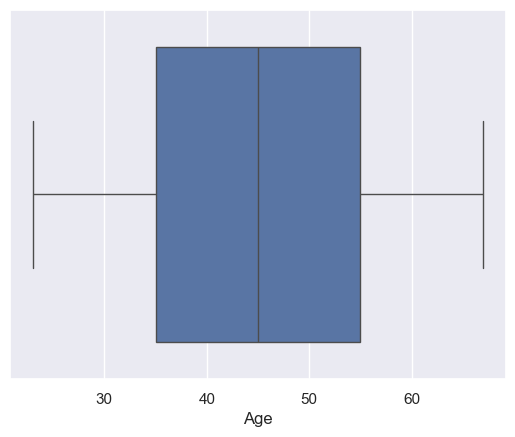

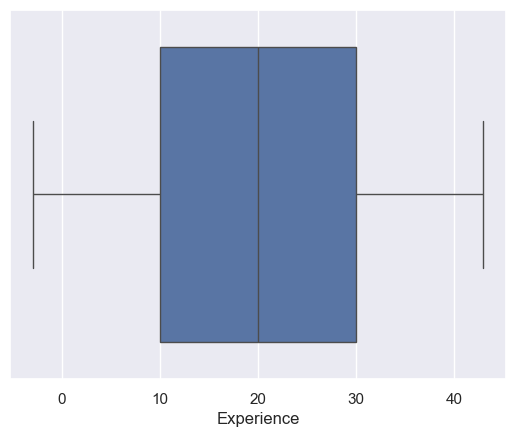

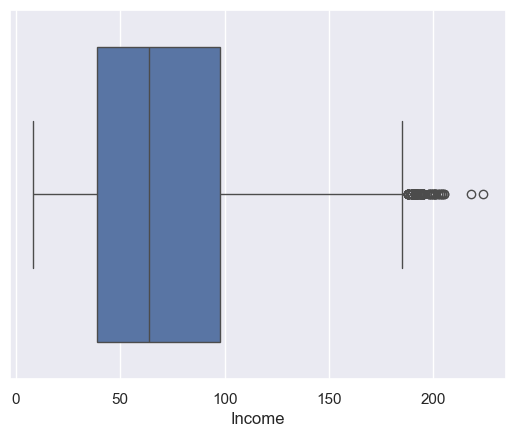

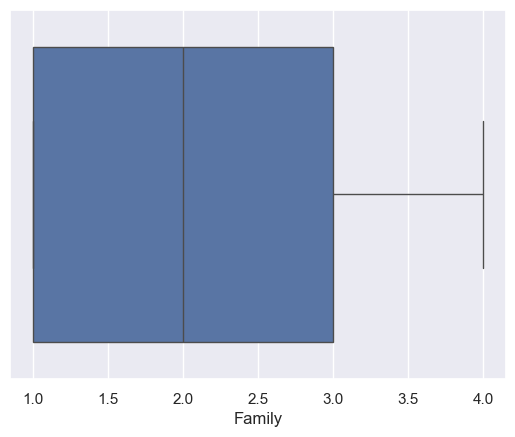

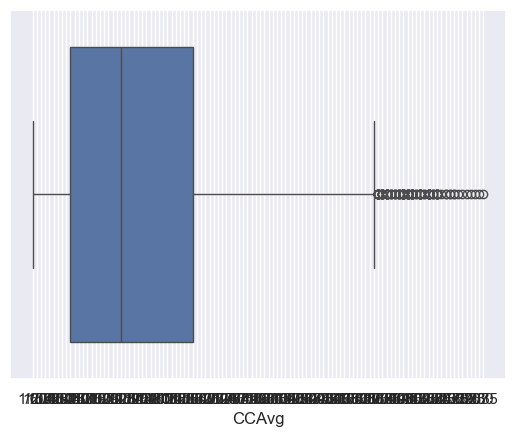

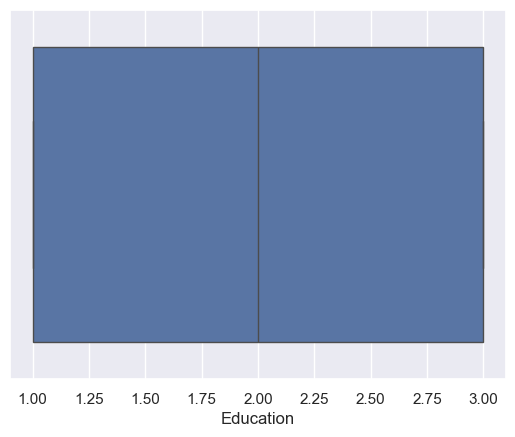

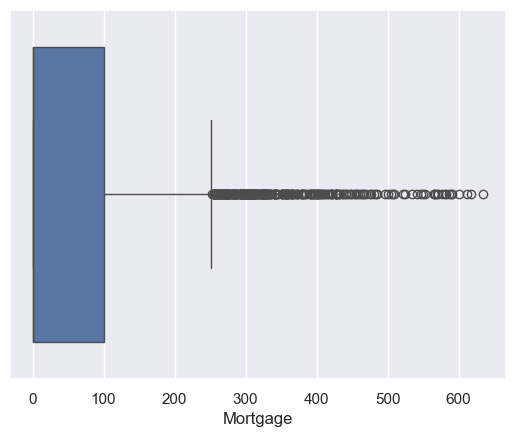

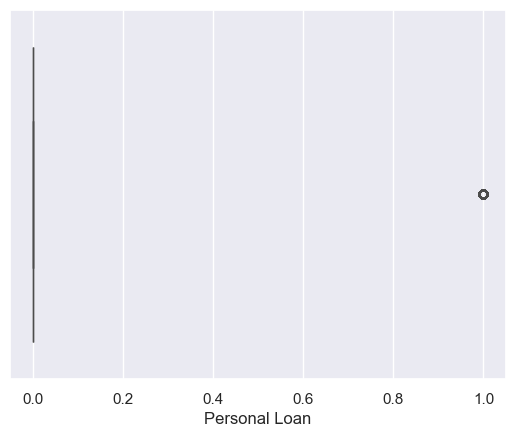

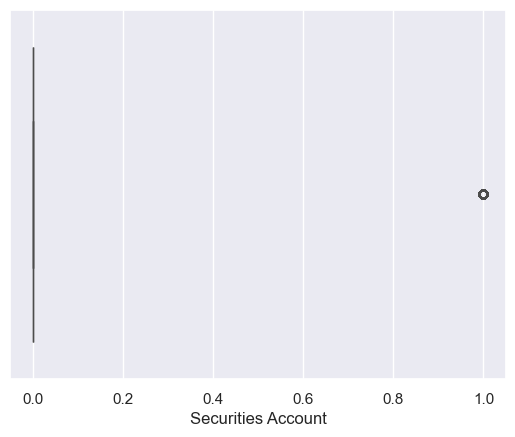

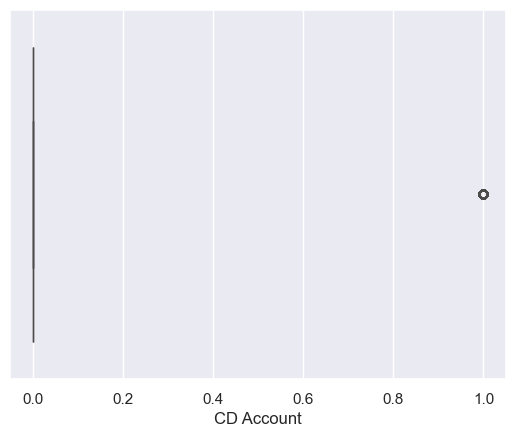

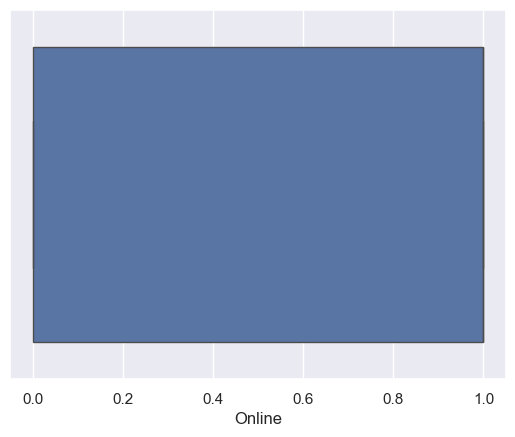

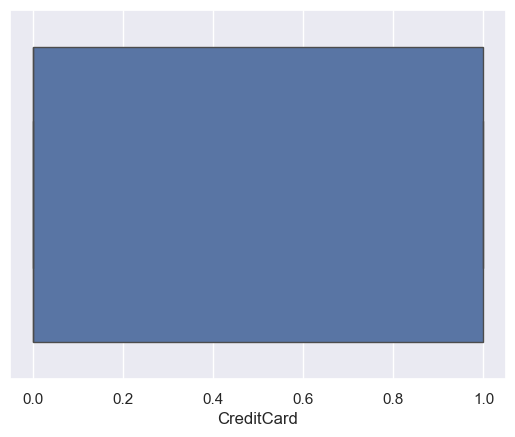

In [93]:
for i in data.columns:
    sns.boxplot(data=data,x=data[i])
    plt.show()

In [94]:
q1=data.quantile(0.25, numeric_only=True)
q3=data.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

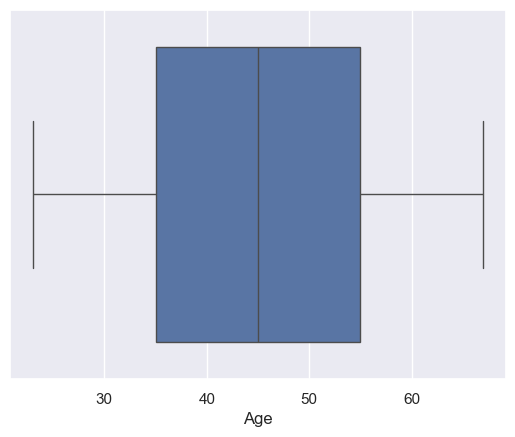

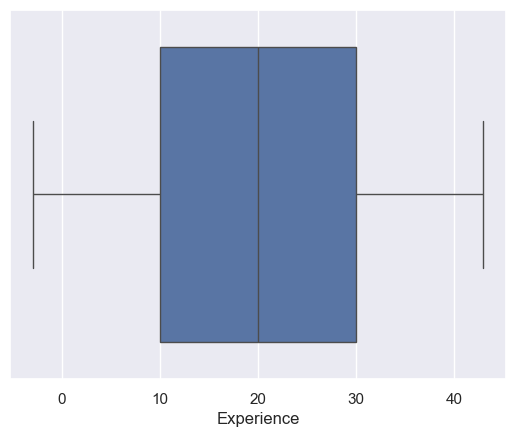

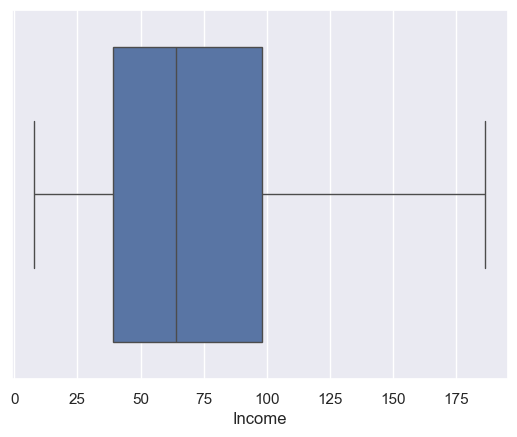

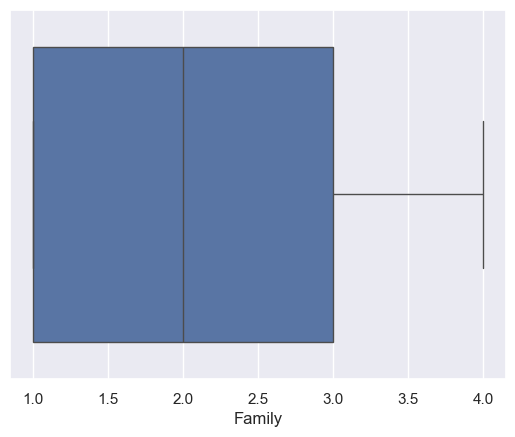

KeyError: 'CCAvg'

In [95]:
for i in data.columns:
    if i == 'Securities Account' or i == 'CD Account':
        continue
    else:
        data[i] = np.where(data[i] > Upper[i],Upper[i],data[i])
        data[i] = np.where(data[i] < Lower[i],Lower[i],data[i])
        sns.boxplot(data=data,x=data[i])
        plt.show()

In [96]:
for i in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[i] = le.fit_transform(data[i])

C:\Users\Asus\AppData\Local\Temp\ipykernel_17844\2413464950.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in data.select_dtypes(include=['object']).columns:


Text(0.5, 1.0, 'Visualization of raw data')

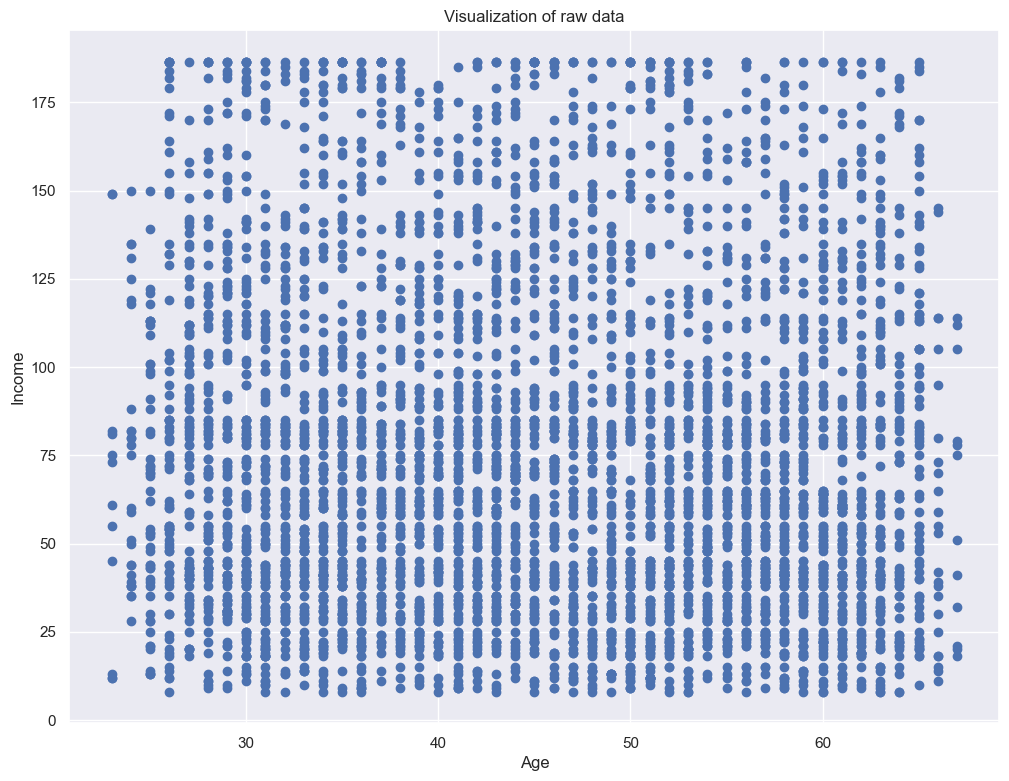

In [98]:
plt.figure(figsize = (12, 9))
plt.scatter(data['Age'], data['Income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Visualization of raw data')

In [99]:
scaler = StandardScaler()
data_std = scaler.fit_transform(data)

data_scaled = pd.DataFrame(data_std, columns=data.columns)
data_scaled.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,-1.774417,-1.666078,-0.539600,1.397414,-0.238437,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
1,-0.029524,-0.096330,-0.868392,0.525991,-0.282863,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
2,-0.552992,-0.445163,-1.372540,-1.216855,-0.549422,-1.049078,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
3,-0.901970,-0.968413,0.578292,-1.216855,0.472386,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
4,-0.901970,-1.055621,-0.627278,1.397414,-0.549422,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,1.549632


### Modelling

In [100]:

wcss = []
silhouette_scores = []

for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)  
    kmeans.fit(data_scaled)
    
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)
    
    print(f"Cluster {i}: WCSS = {wcss_iter:.4f}")  # Print WCSS first
    
    if i > 1:  # Calculate silhouette score only if k >= 2
        y = kmeans.predict(data_scaled)
        silhouette_avg = silhouette_score(data_scaled, y)
        silhouette_scores.append(silhouette_avg)
        print(f"Silhouette Score = {silhouette_avg:.4f}")  
    else:
        print(" (Silhouette Score not applicable for k=1)")  


Cluster 1: WCSS = 60000.0000
 (Silhouette Score not applicable for k=1)
Cluster 2: WCSS = 52436.5822
Silhouette Score = 0.1342
Cluster 3: WCSS = 45502.8816
Silhouette Score = 0.1487
Cluster 4: WCSS = 40727.4604
Silhouette Score = 0.1568
Cluster 5: WCSS = 37682.6611
Silhouette Score = 0.1680
Cluster 6: WCSS = 34852.1729
Silhouette Score = 0.1792
Cluster 7: WCSS = 32957.1804
Silhouette Score = 0.1657


The optimal number of clusters (elbow point) is: 4


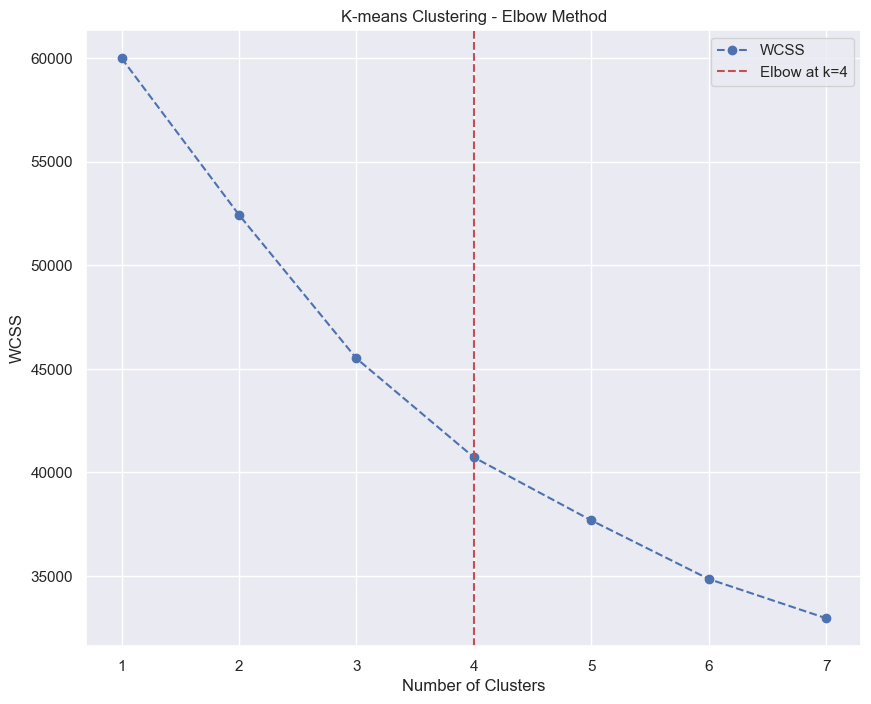

In [101]:
from kneed import KneeLocator

# Automatically find the "elbow"
knee_locator = KneeLocator(range(1, 8), wcss, curve="convex", direction="decreasing")

#Convex Curve: The plot is shaped like a gradually flattening downward curve.
#WCSS is always decreasing as we increase the number of clusters.

# Get the elbow point
optimal_k = knee_locator.elbow
print(f"The optimal number of clusters (elbow point) is: {optimal_k}")

# Plot with the elbow point marked
plt.figure(figsize=(10, 8))
plt.plot(range(1, 8), wcss, marker="o", linestyle="--", label="WCSS")
plt.axvline(optimal_k, linestyle="--", color="r", label=f"Elbow at k={optimal_k}")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("K-means Clustering - Elbow Method")
plt.legend()
plt.show()


In [102]:
kmeans = KMeans(3)
kmeans.fit(data_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [103]:
data['Segment_KM'] = kmeans.predict(data_scaled)
data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Segment_KM
0,25.0,1.0,49.0,4.0,19,1,0,0,1,0,0,0,1
1,45.0,19.0,34.0,3.0,18,1,0,0,1,0,0,0,1
2,39.0,15.0,11.0,1.0,12,1,0,0,0,0,0,0,1
3,35.0,9.0,100.0,1.0,35,2,0,0,0,0,0,0,1
4,35.0,8.0,45.0,4.0,12,2,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,24,3,0,0,0,0,1,0,1
4996,30.0,4.0,15.0,4.0,4,1,85,0,0,0,1,0,1
4997,63.0,39.0,24.0,2.0,3,3,0,0,0,0,0,0,0
4998,65.0,40.0,49.0,3.0,5,2,0,0,0,0,1,0,0


In [104]:
df_segm_analysis = data.groupby(['Segment_KM'], as_index=False).mean()
df_segm_analysis

,Segment_KM,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,0,55.363636,30.058905,58.872217,2.345083,17.320501,1.907699,47.856215,0.000000,0.096475,0.032468,0.610390,0.300557
1,1,35.303075,10.071742,60.858712,2.530991,18.330893,1.899951,47.473402,0.000000,0.103465,0.028795,0.576867,0.281601
2,2,44.015094,18.967296,146.489308,2.188679,59.033962,1.759748,103.198742,0.603774,0.128302,0.217610,0.611321,0.308176


In [105]:
df_segm_analysis['data count'] = data.groupby(['Segment_KM']).size()
df_segm_analysis['data proportion'] = df_segm_analysis['data count'] / df_segm_analysis['data count'].sum()

df_segm_analysis

,Segment_KM,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,data count,data proportion
0,0,55.363636,30.058905,58.872217,2.345083,17.320501,1.907699,47.856215,0.000000,0.096475,0.032468,0.610390,0.300557,2156,0.4312
1,1,35.303075,10.071742,60.858712,2.530991,18.330893,1.899951,47.473402,0.000000,0.103465,0.028795,0.576867,0.281601,2049,0.4098
2,2,44.015094,18.967296,146.489308,2.188679,59.033962,1.759748,103.198742,0.603774,0.128302,0.217610,0.611321,0.308176,795,0.1590


I choose segment 2 for cashback purposes as this segment spend a lot on average

C:\Users\Asus\AppData\Local\Temp\ipykernel_17844\2129966598.py:6: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(x=data['Age'], y=data['Income'], hue=data['Segment_KM'], palette=['blue', 'red', 'yellow', 'black'], s=100, edgecolor="black")


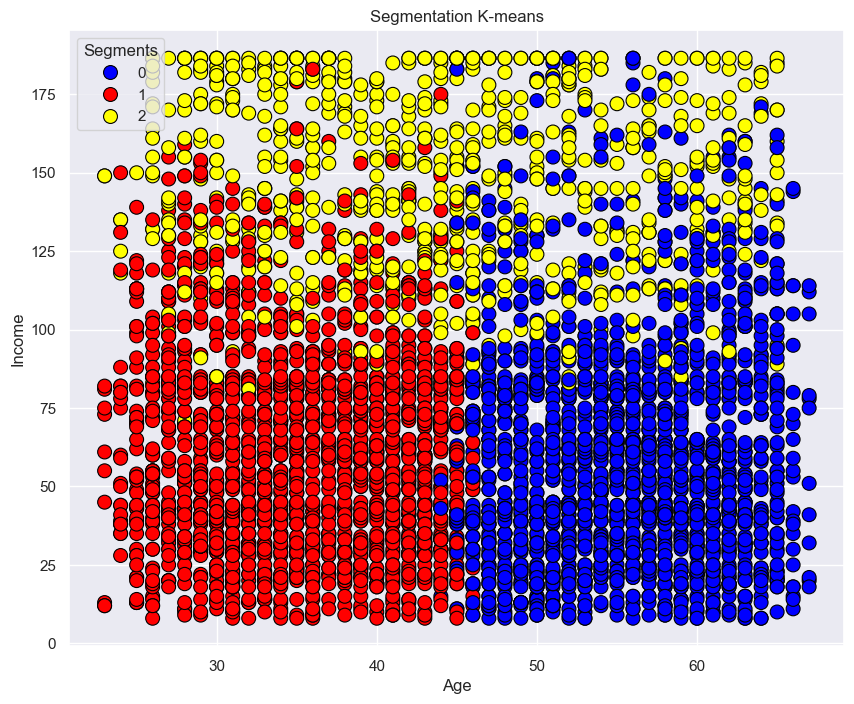

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.scatterplot(x=data['Age'], y=data['Income'], hue=data['Segment_KM'], palette=['blue', 'red', 'yellow', 'black'], s=100, edgecolor="black")

plt.title('Segmentation K-means')
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend(title="Segments")
plt.show()


In [107]:
pca = PCA()

pca.fit(data_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [108]:
pca.explained_variance_ratio_

array([0.18856401, 0.16525611, 0.11837832, 0.09550997, 0.08464409,
       0.08235575, 0.07878501, 0.07695878, 0.04785647, 0.03662928,
       0.02461615, 0.00044606])

Text(0, 0.5, 'Cumulative Explained Variance')

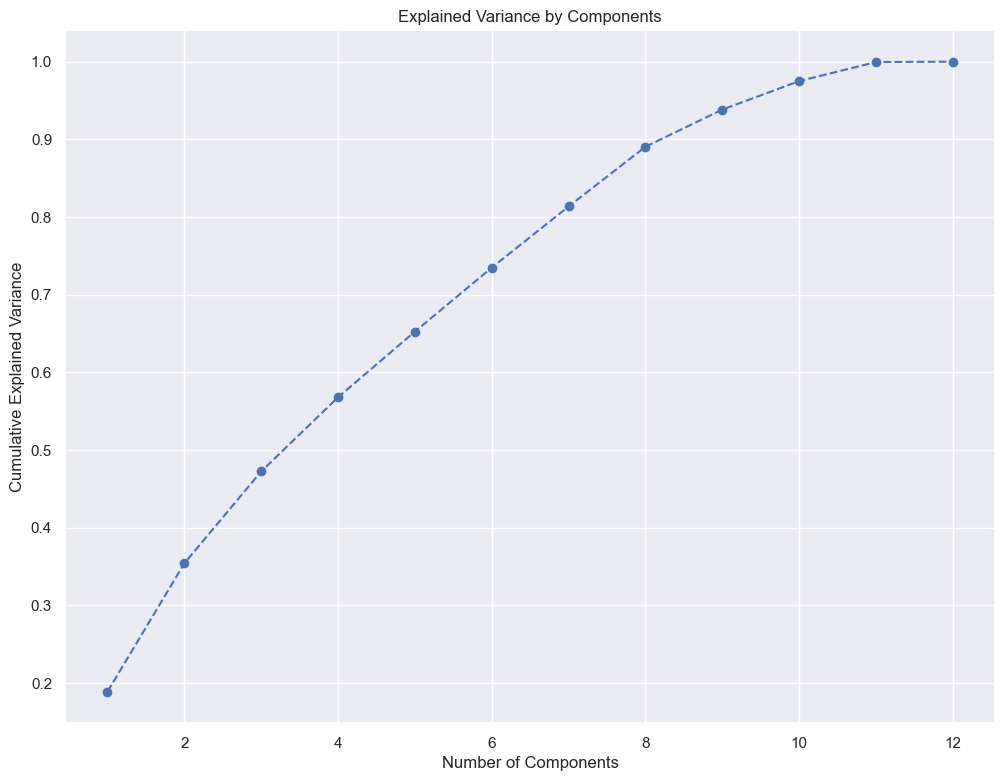

In [110]:
# Plot the cumulative variance explained by total number of components.
# On this graph we choose the subset of components we want to keep. 

# BEST PRACTICE around 80 % of the explained variance.
plt.figure(figsize = (12,9))
plt.plot(range(1,13), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [111]:
pca = PCA(n_components = 7)

In [112]:
pca.fit(data_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",7
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [113]:
pca.components_

array([[-0.20446097, -0.19962524,  0.55142962, -0.07756277,  0.49915383,
        -0.10531341,  0.21296865,  0.45146807,  0.08596644,  0.29344975,
         0.04524688,  0.05727202],
       [ 0.67217534,  0.67335835,  0.13560102, -0.08909577,  0.11401186,
         0.00886858,  0.06172964,  0.15419455,  0.04806768,  0.14430382,
         0.04693593,  0.04941871],
       [-0.04597696, -0.05276816, -0.23279869,  0.26868016, -0.22923083,
         0.23848346, -0.06634953,  0.0879537 ,  0.44046644,  0.58651042,
         0.25202389,  0.38162407],
       [ 0.02207057,  0.00275895, -0.01745921,  0.42635659, -0.03379693,
         0.67396236,  0.10096618,  0.43087908, -0.21276403, -0.13172664,
        -0.20784115, -0.24573093],
       [-0.00758493, -0.00699558,  0.00797016, -0.02404622, -0.02132586,
         0.04056187,  0.04720668,  0.01386763, -0.60883939,  0.01689488,
        -0.16485866,  0.77238703],
       [-0.0047386 , -0.00503926,  0.02092567,  0.11026982, -0.00739942,
         0.00127571, -

In [114]:
df_pca_comp = pd.DataFrame(data = pca.components_,
                           columns = data.columns[:-1].values,
                           index = ['Component 1', 'Component 2', 'Component 3', 'Component 4', 'Component 5', 'Component 6', 'Component 7'])
df_pca_comp

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Component 1,-0.204461,-0.199625,0.551430,-0.077563,0.499154,-0.105313,0.212969,0.451468,0.085966,0.293450,0.045247,0.057272
Component 2,0.672175,0.673358,0.135601,-0.089096,0.114012,0.008869,0.061730,0.154195,0.048068,0.144304,0.046936,0.049419
Component 3,-0.045977,-0.052768,-0.232799,0.268680,-0.229231,0.238483,-0.066350,0.087954,0.440466,0.586510,0.252024,0.381624
Component 4,0.022071,0.002759,-0.017459,0.426357,-0.033797,0.673962,0.100966,0.430879,-0.212764,-0.131727,-0.207841,-0.245731
Component 5,-0.007585,-0.006996,0.007970,-0.024046,-0.021326,0.040562,0.047207,0.013868,-0.608839,0.016895,-0.164859,0.772387
Component 6,-0.004739,-0.005039,0.020926,0.110270,-0.007399,0.001276,-0.001982,0.027794,-0.415408,-0.034815,0.891522,-0.133924
Component 7,0.023448,0.031430,-0.058842,0.421948,-0.152174,-0.338651,0.814399,-0.116726,0.017351,-0.010358,-0.040339,-0.014544


In [115]:
scores_pca = pca.transform(data_scaled)

scores_pca

array([[ 1.00865879e-01, -2.61808439e+00,  1.07174055e+00, ...,
        -2.16638538e+00, -2.05400989e+00,  6.16499603e-01],
       [-7.05149304e-01, -3.60216635e-01,  7.61275093e-01, ...,
        -2.17132024e+00, -2.17283173e+00,  3.65163231e-01],
       [-1.08549979e+00, -1.04763963e+00, -9.26524324e-01, ...,
        -1.30223259e-01, -1.01083019e+00, -3.79979089e-01],
       ...,
       [-2.29227953e+00,  1.70568151e+00, -3.05822184e-01, ...,
        -7.43027072e-02, -9.23248128e-01, -6.59844752e-01],
       [-1.84878340e+00,  1.97361061e+00, -2.46431579e-03, ...,
        -4.79093998e-01,  9.98295676e-01, -1.00591353e-02],
       [ 2.10901818e-01, -2.08591805e+00,  6.40864668e-01, ...,
         1.21560397e+00,  7.47889301e-01,  1.09254855e-01]],
      shape=(5000, 7))

In [116]:
pca_df = pd.DataFrame(scores_pca, columns=[f'Variable_{i+1}' for i in range(scores_pca.shape[1])])

pca_df


,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7
0,0.100866,-2.618084,1.071741,-0.512357,-2.166385,-2.054010,0.616500
1,-0.705149,-0.360217,0.761275,-0.833810,-2.171320,-2.172832,0.365163
2,-1.085500,-1.047640,-0.926524,-0.875778,-0.130223,-1.010830,-0.379979
3,0.550687,-1.242955,-1.287268,-0.150977,-0.081858,-0.971759,-1.078151
4,-0.683791,-1.706101,0.772266,0.479610,1.563419,-0.994667,0.216701
...,...,...,...,...,...,...,...
4995,-0.240151,-2.074964,-0.019648,0.254347,-0.362063,0.828401,-1.440611
4996,-0.795055,-2.335658,0.381975,-0.109978,-0.468764,1.106236,1.321879
4997,-2.292280,1.705682,-0.305822,1.161367,-0.074303,-0.923248,-0.659845
4998,-1.848783,1.973611,-0.002464,0.298185,-0.479094,0.998296,-0.010059


## K means PCA Modelling

In [117]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss_pca = []
silhouette_scores_pca = []

for i in range(1, 8):
    kmeans_pca = KMeans(n_clusters=i, random_state=42)  
    kmeans_pca.fit(pca_df)
    
    wcss_iter = kmeans_pca.inertia_
    wcss_pca.append(wcss_iter)
    
    print(f"Cluster {i}: WCSS = {wcss_iter:.4f}")  # Print WCSS first
    
    if i > 1:  # Calculate silhouette score only if k >= 2
        y = kmeans_pca.predict(pca_df)
        silhouette_avg = silhouette_score(pca_df, y)
        silhouette_scores_pca.append(silhouette_avg)
        print(f"Silhouette Score = {silhouette_avg:.4f}")  # Append silhouette score to output
    else:
        print(" (Silhouette Score not applicable for k=1)")  # Indicate skipping silhouette score


Cluster 1: WCSS = 48809.5952
 (Silhouette Score not applicable for k=1)
Cluster 2: WCSS = 43758.1244
Silhouette Score = 0.1249
Cluster 3: WCSS = 38332.6900
Silhouette Score = 0.1508
Cluster 4: WCSS = 32077.6876
Silhouette Score = 0.1535
Cluster 5: WCSS = 29161.6520
Silhouette Score = 0.1678
Cluster 6: WCSS = 27345.3076
Silhouette Score = 0.1678
Cluster 7: WCSS = 24862.7980
Silhouette Score = 0.1765


The optimal number of clusters (elbow point) is: 4


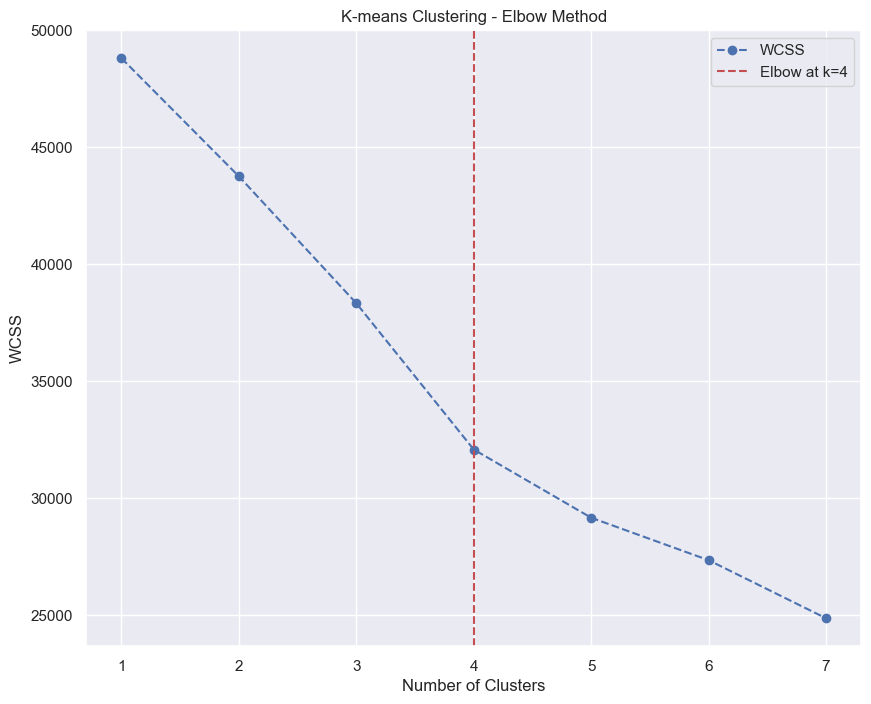

In [120]:
from kneed import KneeLocator

# Automatically find the "elbow"
knee_locator = KneeLocator(range(1, 8), wcss_pca, curve="convex", direction="decreasing")

#Convex Curve: The plot is shaped like a gradually flattening downward curve.
#WCSS is always decreasing as we increase the number of clusters.

# Get the elbow point
optimal_k = knee_locator.elbow
print(f"The optimal number of clusters (elbow point) is: {optimal_k}")

# Plot with the elbow point marked
plt.figure(figsize=(10, 8))
plt.plot(range(1, 8), wcss_pca, marker="o", linestyle="--", label="WCSS")
plt.axvline(optimal_k, linestyle="--", color="r", label=f"Elbow at k={optimal_k}")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("K-means Clustering - Elbow Method")
plt.legend()
plt.show()


In [121]:
kmeans_pca = KMeans(4)
kmeans_pca.fit(pca_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [122]:
data['Segment_KM_PCA'] = kmeans_pca.predict(pca_df)
data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Segment_KM,Segment_KM_PCA
0,25.0,1.0,49.0,4.0,19,1,0,0,1,0,0,0,1,0
1,45.0,19.0,34.0,3.0,18,1,0,0,1,0,0,0,1,0
2,39.0,15.0,11.0,1.0,12,1,0,0,0,0,0,0,1,0
3,35.0,9.0,100.0,1.0,35,2,0,0,0,0,0,0,1,0
4,35.0,8.0,45.0,4.0,12,2,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,24,3,0,0,0,0,1,0,1,0
4996,30.0,4.0,15.0,4.0,4,1,85,0,0,0,1,0,1,0
4997,63.0,39.0,24.0,2.0,3,3,0,0,0,0,0,0,0,3
4998,65.0,40.0,49.0,3.0,5,2,0,0,0,0,1,0,0,3


In [123]:
data = pd.concat([data,pca_df], axis=1)

data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,...,CreditCard,Segment_KM,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7
0,25.0,1.0,49.0,4.0,19,1,0,0,1,0,...,0,1,0,0.100866,-2.618084,1.071741,-0.512357,-2.166385,-2.054010,0.616500
1,45.0,19.0,34.0,3.0,18,1,0,0,1,0,...,0,1,0,-0.705149,-0.360217,0.761275,-0.833810,-2.171320,-2.172832,0.365163
2,39.0,15.0,11.0,1.0,12,1,0,0,0,0,...,0,1,0,-1.085500,-1.047640,-0.926524,-0.875778,-0.130223,-1.010830,-0.379979
3,35.0,9.0,100.0,1.0,35,2,0,0,0,0,...,0,1,0,0.550687,-1.242955,-1.287268,-0.150977,-0.081858,-0.971759,-1.078151
4,35.0,8.0,45.0,4.0,12,2,0,0,0,0,...,1,1,0,-0.683791,-1.706101,0.772266,0.479610,1.563419,-0.994667,0.216701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,24,3,0,0,0,0,...,0,1,0,-0.240151,-2.074964,-0.019648,0.254347,-0.362063,0.828401,-1.440611
4996,30.0,4.0,15.0,4.0,4,1,85,0,0,0,...,0,1,0,-0.795055,-2.335658,0.381975,-0.109978,-0.468764,1.106236,1.321879
4997,63.0,39.0,24.0,2.0,3,3,0,0,0,0,...,0,0,3,-2.292280,1.705682,-0.305822,1.161367,-0.074303,-0.923248,-0.659845
4998,65.0,40.0,49.0,3.0,5,2,0,0,0,0,...,0,0,3,-1.848783,1.973611,-0.002464,0.298185,-0.479094,0.998296,-0.010059


C:\Users\Asus\AppData\Local\Temp\ipykernel_17844\3151265422.py:3: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x=data['Variable_2'], y=data['Variable_1'], hue=data['Segment_KM_PCA'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")


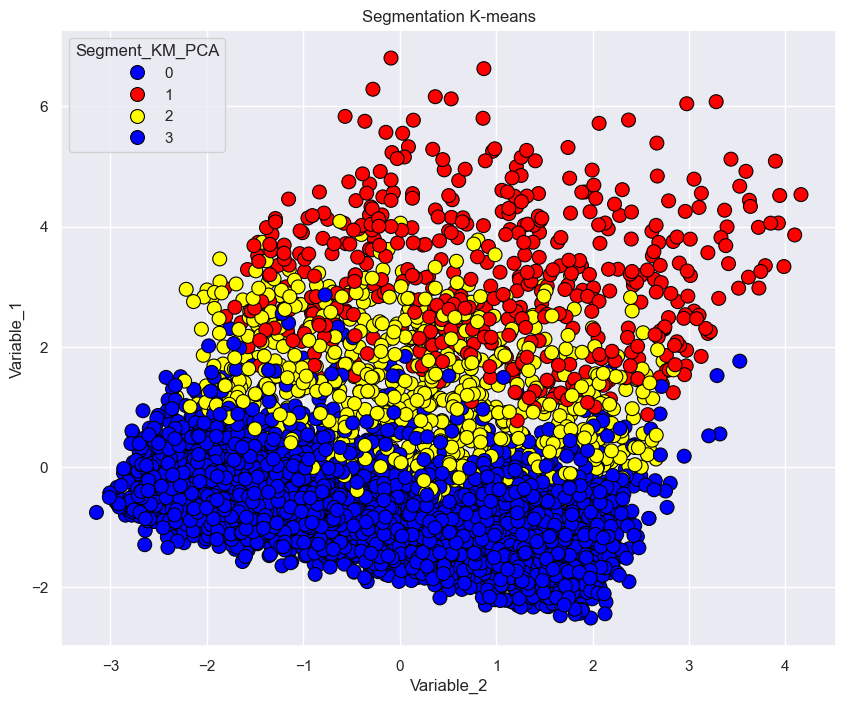

In [124]:
plt.figure(figsize=(10, 8))

sns.scatterplot(x=data['Variable_2'], y=data['Variable_1'], hue=data['Segment_KM_PCA'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")

plt.title('Segmentation K-means')
plt.xlabel("Variable_2")
plt.ylabel("Variable_1")
plt.legend(title="Segment_KM_PCA")
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_17844\616997063.py:3: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x=data['Age'], y=data['Income'], hue=data['Segment_KM_PCA'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")


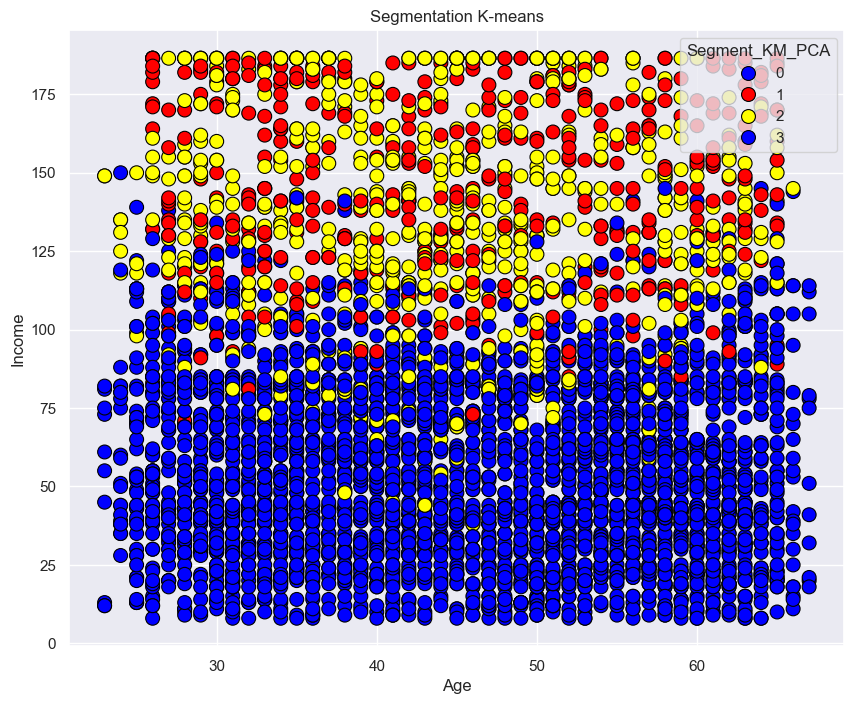

In [125]:
plt.figure(figsize=(10, 8))

sns.scatterplot(x=data['Age'], y=data['Income'], hue=data['Segment_KM_PCA'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")

plt.title('Segmentation K-means')
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend(title="Segment_KM_PCA")
plt.show()

In [126]:
df_segm_analysis_pca = data.groupby(['Segment_KM_PCA'], as_index=False).mean()
df_segm_analysis_pca

,Segment_KM_PCA,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,Online,CreditCard,Segment_KM,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7
0,0,35.144026,9.858702,55.509002,2.666121,16.449536,1.981997,46.010366,0.001637,0.108565,...,0.574468,0.294599,0.998909,-0.267943,-1.387895,0.255804,0.051699,0.005438,-0.021832,0.043099
1,1,44.966000,19.776000,144.105000,2.592000,50.288000,2.218000,102.180000,0.940000,0.152000,...,0.634000,0.344000,1.988000,3.140302,0.943364,0.560959,1.325796,0.058633,0.069538,-0.314529
2,2,44.323848,19.453930,128.859756,1.462060,49.871274,1.046070,87.758808,0.008130,0.071816,...,0.578591,0.227642,1.081301,1.281137,0.188296,-1.270947,-1.082658,-0.068835,-0.044369,0.034662
3,3,55.510109,30.174702,51.419388,2.446864,15.414204,2.017107,42.665111,0.000518,0.100570,...,0.615345,0.305858,0.008294,-1.049502,1.002264,0.097766,0.021430,0.005970,0.019695,0.027312


In [127]:
df_segm_analysis_pca['data count'] = data.groupby(['Segment_KM_PCA']).size()
df_segm_analysis_pca['data proportion'] = df_segm_analysis_pca['data count'] / df_segm_analysis_pca['data count'].sum()

df_segm_analysis_pca

,Segment_KM_PCA,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,Segment_KM,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,data count,data proportion
0,0,35.144026,9.858702,55.509002,2.666121,16.449536,1.981997,46.010366,0.001637,0.108565,...,0.998909,-0.267943,-1.387895,0.255804,0.051699,0.005438,-0.021832,0.043099,1833,0.3666
1,1,44.966000,19.776000,144.105000,2.592000,50.288000,2.218000,102.180000,0.940000,0.152000,...,1.988000,3.140302,0.943364,0.560959,1.325796,0.058633,0.069538,-0.314529,500,0.1000
2,2,44.323848,19.453930,128.859756,1.462060,49.871274,1.046070,87.758808,0.008130,0.071816,...,1.081301,1.281137,0.188296,-1.270947,-1.082658,-0.068835,-0.044369,0.034662,738,0.1476
3,3,55.510109,30.174702,51.419388,2.446864,15.414204,2.017107,42.665111,0.000518,0.100570,...,0.008294,-1.049502,1.002264,0.097766,0.021430,0.005970,0.019695,0.027312,1929,0.3858


- I choose segment 2 again as Variable 3 has the highest value for this segment.
- Income had the greatest impact in Component 3 (Variable 3)

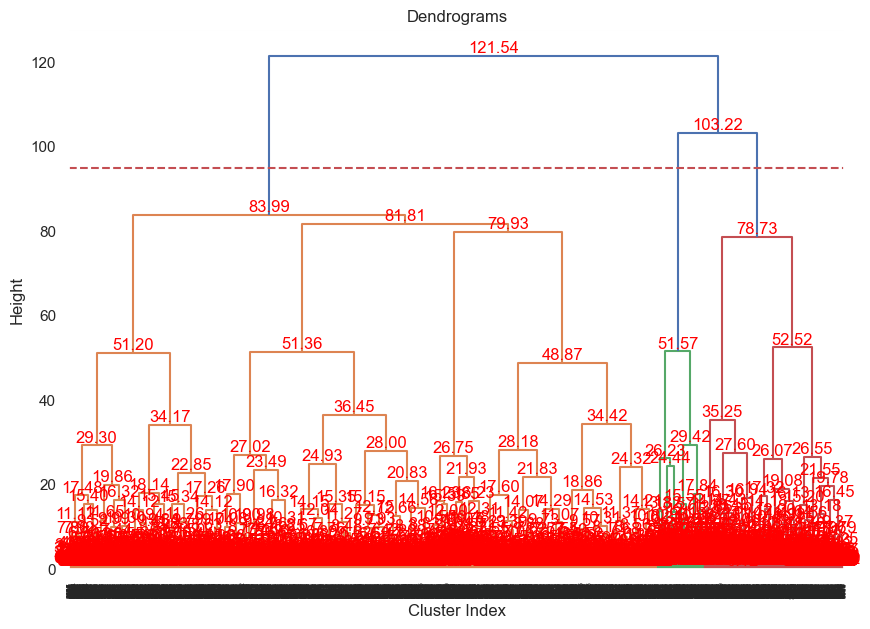

In [157]:
plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  

dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
# Label heights
for x, y in zip(dend['icoord'], dend['dcoord']):
    plt.text((x[1] + x[2]) / 2, y[1], f"{y[1]:.2f}", ha='center', va='bottom', color='red')

plt.xlabel("Cluster Index")
plt.ylabel("Height")
plt.axhline(y=95, color='r', linestyle='--')
plt.show()

In [146]:
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')  
y = cluster.fit_predict(data_scaled)
y

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

In [147]:
data['segment_HC'] = y

data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,...,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,segment_HC,segment_HC_PCA
0,25.0,1.0,49.0,4.0,19,1,0,0,1,0,...,0,0.100866,-2.618084,1.071741,-0.512357,-2.166385,-2.054010,0.616500,0,1
1,45.0,19.0,34.0,3.0,18,1,0,0,1,0,...,0,-0.705149,-0.360217,0.761275,-0.833810,-2.171320,-2.172832,0.365163,0,1
2,39.0,15.0,11.0,1.0,12,1,0,0,0,0,...,0,-1.085500,-1.047640,-0.926524,-0.875778,-0.130223,-1.010830,-0.379979,0,1
3,35.0,9.0,100.0,1.0,35,2,0,0,0,0,...,0,0.550687,-1.242955,-1.287268,-0.150977,-0.081858,-0.971759,-1.078151,0,1
4,35.0,8.0,45.0,4.0,12,2,0,0,0,0,...,0,-0.683791,-1.706101,0.772266,0.479610,1.563419,-0.994667,0.216701,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,24,3,0,0,0,0,...,0,-0.240151,-2.074964,-0.019648,0.254347,-0.362063,0.828401,-1.440611,0,1
4996,30.0,4.0,15.0,4.0,4,1,85,0,0,0,...,0,-0.795055,-2.335658,0.381975,-0.109978,-0.468764,1.106236,1.321879,0,1
4997,63.0,39.0,24.0,2.0,3,3,0,0,0,0,...,3,-2.292280,1.705682,-0.305822,1.161367,-0.074303,-0.923248,-0.659845,0,2
4998,65.0,40.0,49.0,3.0,5,2,0,0,0,0,...,3,-1.848783,1.973611,-0.002464,0.298185,-0.479094,0.998296,-0.010059,0,2


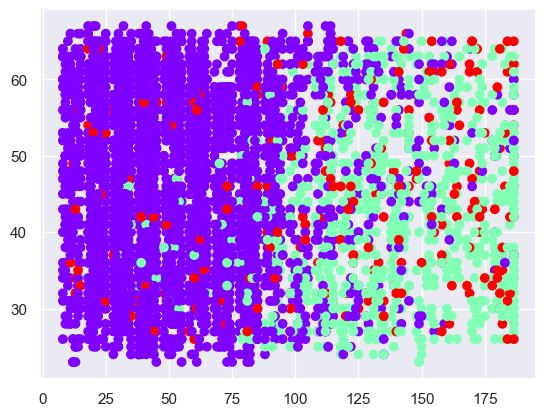

In [148]:
plt.scatter(data['Income'],data['Age'],c=data['segment_HC'],cmap='rainbow')
plt.xlim()
plt.ylim()
plt.show()

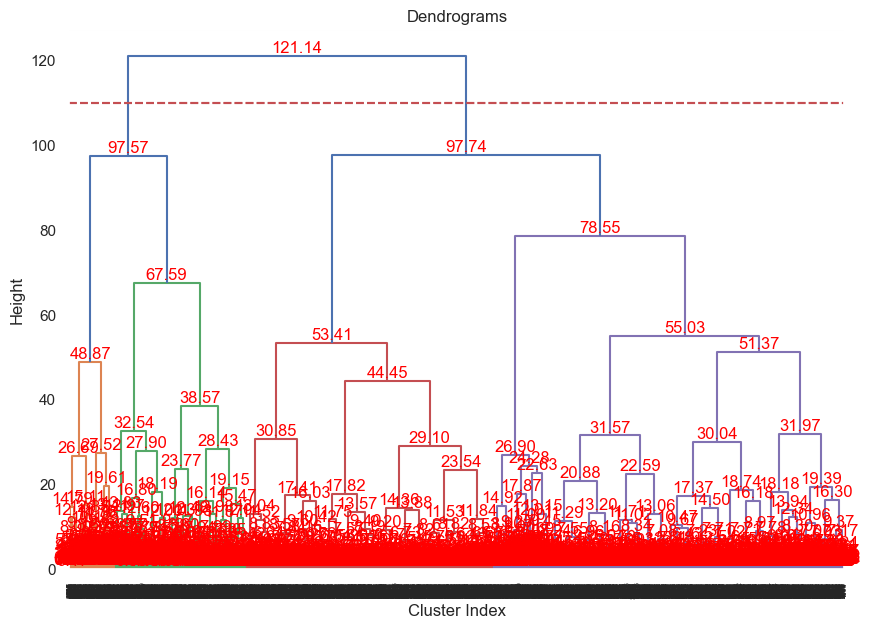

In [149]:
plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  

dend = shc.dendrogram(shc.linkage(pca_df, method='ward'))
plt.axhline(y=110, color='r', linestyle='--')

# Label heights
for x, y in zip(dend['icoord'], dend['dcoord']):
    plt.text((x[1] + x[2]) / 2, y[1], f"{y[1]:.2f}", ha='center', va='bottom', color='red')

plt.xlabel("Cluster Index")
plt.ylabel("Height")
plt.axhline(y=110, color='r', linestyle='--')
plt.show()

In [150]:
cluster = AgglomerativeClustering(n_clusters=2, linkage='ward')  
y = cluster.fit_predict(pca_df)
y

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

In [151]:
data['segment_HC_PCA'] = y

data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,...,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,segment_HC,segment_HC_PCA
0,25.0,1.0,49.0,4.0,19,1,0,0,1,0,...,0,0.100866,-2.618084,1.071741,-0.512357,-2.166385,-2.054010,0.616500,0,0
1,45.0,19.0,34.0,3.0,18,1,0,0,1,0,...,0,-0.705149,-0.360217,0.761275,-0.833810,-2.171320,-2.172832,0.365163,0,0
2,39.0,15.0,11.0,1.0,12,1,0,0,0,0,...,0,-1.085500,-1.047640,-0.926524,-0.875778,-0.130223,-1.010830,-0.379979,0,0
3,35.0,9.0,100.0,1.0,35,2,0,0,0,0,...,0,0.550687,-1.242955,-1.287268,-0.150977,-0.081858,-0.971759,-1.078151,0,0
4,35.0,8.0,45.0,4.0,12,2,0,0,0,0,...,0,-0.683791,-1.706101,0.772266,0.479610,1.563419,-0.994667,0.216701,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,24,3,0,0,0,0,...,0,-0.240151,-2.074964,-0.019648,0.254347,-0.362063,0.828401,-1.440611,0,0
4996,30.0,4.0,15.0,4.0,4,1,85,0,0,0,...,0,-0.795055,-2.335658,0.381975,-0.109978,-0.468764,1.106236,1.321879,0,0
4997,63.0,39.0,24.0,2.0,3,3,0,0,0,0,...,3,-2.292280,1.705682,-0.305822,1.161367,-0.074303,-0.923248,-0.659845,0,0
4998,65.0,40.0,49.0,3.0,5,2,0,0,0,0,...,3,-1.848783,1.973611,-0.002464,0.298185,-0.479094,0.998296,-0.010059,0,0


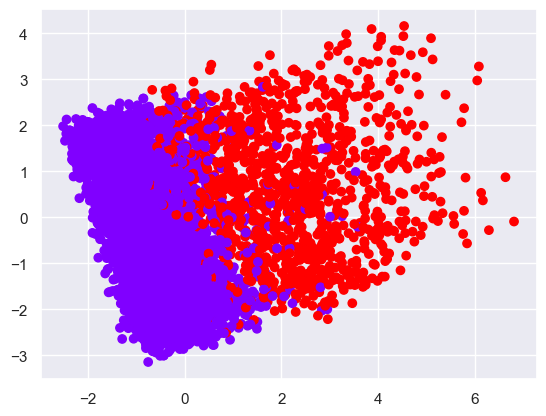

In [152]:
plt.scatter(data['Variable_1'], data['Variable_2'],c=data['segment_HC_PCA'],cmap='rainbow')
plt.xlim()
plt.ylim()
plt.show()

In [153]:
df_segm_analysis_agl = data.groupby(['segment_HC_PCA'], as_index=False).mean()
df_segm_analysis_agl

,segment_HC_PCA,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,Segment_KM,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,segment_HC
0,0,45.328920,20.042316,56.950415,2.485981,17.167445,1.956127,42.781412,0.000000,0.095016,...,0.509605,1.557113,-0.631047,-0.195516,0.000583,0.008863,-0.023233,0.015553,0.003842,0.043094
1,1,45.370209,20.313589,129.541812,2.095819,48.524390,1.628920,102.526132,0.418118,0.135889,...,1.459930,1.537456,2.117414,0.656034,-0.001957,-0.029740,0.077955,-0.052185,-0.012891,1.164634


In [154]:
df_segm_analysis_agl['data count'] = data.groupby(['segment_HC_PCA']).size()
df_segm_analysis_agl['data proportion'] = df_segm_analysis_agl['data count'] / df_segm_analysis_agl['data count'].sum()

df_segm_analysis_agl

,segment_HC_PCA,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,segment_HC,data count,data proportion
0,0,45.328920,20.042316,56.950415,2.485981,17.167445,1.956127,42.781412,0.000000,0.095016,...,-0.631047,-0.195516,0.000583,0.008863,-0.023233,0.015553,0.003842,0.043094,3852,0.7704
1,1,45.370209,20.313589,129.541812,2.095819,48.524390,1.628920,102.526132,0.418118,0.135889,...,2.117414,0.656034,-0.001957,-0.029740,0.077955,-0.052185,-0.012891,1.164634,1148,0.2296


- I choose segment 1 again as Variable 3 has the highest value for this segment.
- Income had the greatest impact in Component 1 (Variable 1)

In [155]:
data_filtered = data[data['segment_HC_PCA'] == 1]



In [156]:
data_filtered.describe()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,...,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,segment_HC,segment_HC_PCA
count,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,...,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.000000,1148.0
mean,45.370209,20.313589,129.541812,2.095819,48.524390,1.628920,102.526132,0.418118,0.135889,0.263066,...,1.537456,2.117414,0.656034,-0.001957,-0.029740,0.077955,-0.052185,-0.012891,1.164634,1.0
std,11.223794,11.184320,42.715074,1.050370,28.637565,0.819296,152.643130,0.493465,0.342819,0.440490,...,0.745454,1.401623,1.359928,2.116065,1.529133,0.956522,0.940367,1.376372,0.578520,0.0
min,23.000000,-3.000000,11.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.066536,-2.506243,-2.904380,-3.158663,-2.459014,-2.773203,-2.465485,0.000000,1.0
25%,35.000000,10.000000,104.000000,1.000000,26.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.107140,-0.399240,-1.553719,-1.131069,-0.443006,-0.892617,-0.951751,1.000000,1.0
50%,45.000000,20.000000,134.000000,2.000000,46.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,2.051337,0.599397,-0.808424,-0.532193,-0.166296,-0.338577,-0.510549,1.000000,1.0
75%,55.000000,30.000000,164.000000,3.000000,71.000000,2.000000,205.000000,1.000000,0.000000,1.000000,...,2.000000,2.984615,1.713782,1.656058,1.290924,1.195991,0.855778,0.887092,2.000000,1.0
max,67.000000,43.000000,186.500000,4.000000,107.000000,3.000000,635.000000,1.000000,1.000000,1.000000,...,3.000000,6.803045,4.160746,5.486928,3.614076,1.890432,1.277937,4.906522,2.000000,1.0
